# 3 — Is VMD earning its cost, and preparing the quantum handoff

Notebook 2 produced a feature file. This one asks the two questions that decide whether
any of it was worth doing:

1. **Does VMD beat the same statistics computed without VMD?** If 28 descriptors on the
   raw window score as well as 28 descriptors on each of 8 modes, the decomposition is
   decoration.
2. **How much of the score is real?** Split by record, ablate the suspicious mode, and
   see what survives.

Then it reduces ~236 features to a **qubit-sized subset** and writes the arrays the
quantum model will consume.

In [28]:
# --- Bootstrap: works unchanged in VS Code, plain Jupyter, and Google Colab ----------
import os, sys, subprocess

def _bootstrap():
    try:
        import ecgvmd  # noqa: F401
        return os.path.dirname(os.path.dirname(os.path.abspath(ecgvmd.__file__)))
    except ImportError:
        pass
    d = os.path.abspath(os.getcwd())
    for _ in range(4):
        if os.path.isdir(os.path.join(d, "ecgvmd")):
            sys.path.insert(0, d); return d
        d = os.path.dirname(d)
    for cand in ("/content/test-ecg-training", "/content/drive/MyDrive/test-ecg-training"):
        if os.path.isdir(os.path.join(cand, "ecgvmd")):
            sys.path.insert(0, cand); return cand
    try:
        from google.colab import files
        print("Upload ecgvmd_bundle.zip (make it with: python make_colab_bundle.py)")
        up = files.upload()
        import zipfile
        with zipfile.ZipFile(next(iter(up))) as z:
            z.extractall("/content")
        sys.path.insert(0, "/content"); return "/content"
    except ImportError:
        raise ImportError("Could not locate the ecgvmd package.")

IN_COLAB = "google.colab" in sys.modules or os.path.isdir("/content")
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "-q", "install",
                    "numpy", "scipy", "scikit-learn", "pandas", "matplotlib"], check=False)
ROOT = _bootstrap(); os.chdir(ROOT)
print("project root:", ROOT)

project root: /mnt/d/Projects/test-ecg-training


In [29]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ecgvmd as E
from ecgvmd import CLASS_ORDER, CLASS_COLORS

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "figure.facecolor": "white",
    "axes.titlesize": 10, "legend.frameon": False,
})

# quantum_*.npz is written by this notebook and is NOT a FeatureBundle -
# without the filter it becomes the newest match and the load below fails.
cands = [f for f in sorted(glob.glob("features/*.npz"), key=os.path.getmtime, reverse=True)
         if not os.path.basename(f).startswith("quantum_")]
if not cands:
    raise FileNotFoundError("No feature file. Run notebook 2, or:  python run_pipeline.py")
FEATURE_FILE = cands[0]

fb = E.FeatureBundle.load(FEATURE_FILE)
cfg = fb.cfg
print("loaded", FEATURE_FILE)
print(fb.describe())

loaded features/fixed_K8_a2000_L500_it500_eeb2053b.npz
1620 segments from 162 records
config: fs=128 Hz | window=500 (3.91 s) | seg_mode=fixed | K=8 | alpha=2000 | dc=True | max_iter=500
VMD capped fraction: 34.2%
  VMD modes                   227 features
  rhythm only                   9 features
  VMD modes + rhythm          236 features
  control (no VMD)             46 features
  VMD + rhythm + control      282 features


## 3.1 The split, and why it dominates everything

Same features, same model, two cross-validation schemes. The only difference is whether
segments from one recording are allowed to appear in both train and test.

In [30]:
X, names = fb["VMD modes + rhythm"]
gap = E.leakage_gap(X, fb.y, fb.groups, cfg)
for k, v in gap.items():
    print(f"{k:30s} {v:.4f}")
print()
print("That inflation is not a small effect. It is larger than the difference between")
print("most of the modelling choices in this project, and it is entirely artificial.")
print("Published ECG accuracies above ~0.97 on this dataset are usually this bug.")

random split (LEAKY)           0.9009
record-wise split (honest)     0.7861
inflation                      0.1148

That inflation is not a small effect. It is larger than the difference between
most of the modelling choices in this project, and it is entirely artificial.
Published ECG accuracies above ~0.97 on this dataset are usually this bug.


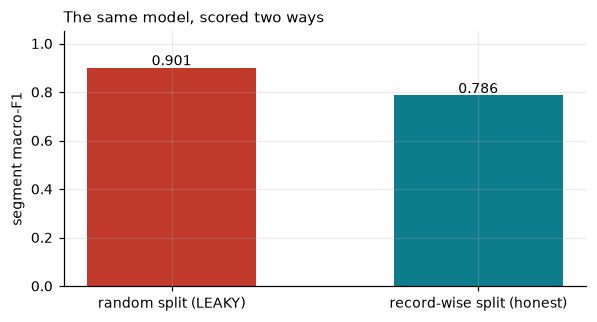

In [31]:
fig, ax = plt.subplots(figsize=(5.5, 3))
ks = ["random split (LEAKY)", "record-wise split (honest)"]
ax.bar(ks, [gap[k] for k in ks], color=["#c0392b", "#0d7c8c"], width=0.55)
for i, k in enumerate(ks):
    ax.text(i, gap[k] + 0.01, f"{gap[k]:.3f}", ha="center", fontsize=9)
ax.set_ylabel("segment macro-F1"); ax.set_ylim(0, 1.05)
ax.set_title("The same model, scored two ways", loc="left")
fig.tight_layout(); plt.show()

## 3.2 Does VMD beat the control?

The control block is the **same 28 descriptors** applied to the undecomposed window,
plus classical fixed-band Fourier powers and their ratios. If VMD contributes nothing,
the two rows tie.

All rows use record-wise splits from here on.

In [32]:
rows = E.compare_blocks(fb, cfg)
set_df = (pd.DataFrame(rows).set_index("feature set")
            .reindex(["control (no VMD)", "rhythm only", "VMD modes",
                      "VMD modes + rhythm", "VMD + rhythm + control"])
            .dropna(how="all"))
print(set_df.round(4).to_string())

                        dim  segment acc  segment bal-acc  segment macro-F1  record acc     n
feature set                                                                                  
control (no VMD)         46       0.7210           0.6299            0.6481      0.7407  1620
rhythm only               9       0.6512           0.5564            0.5640      0.7407  1620
VMD modes               227       0.8019           0.7514            0.7671      0.8519  1620
VMD modes + rhythm      236       0.8167           0.7726            0.7861      0.8642  1620
VMD + rhythm + control  282       0.8074           0.7576            0.7746      0.8519  1620


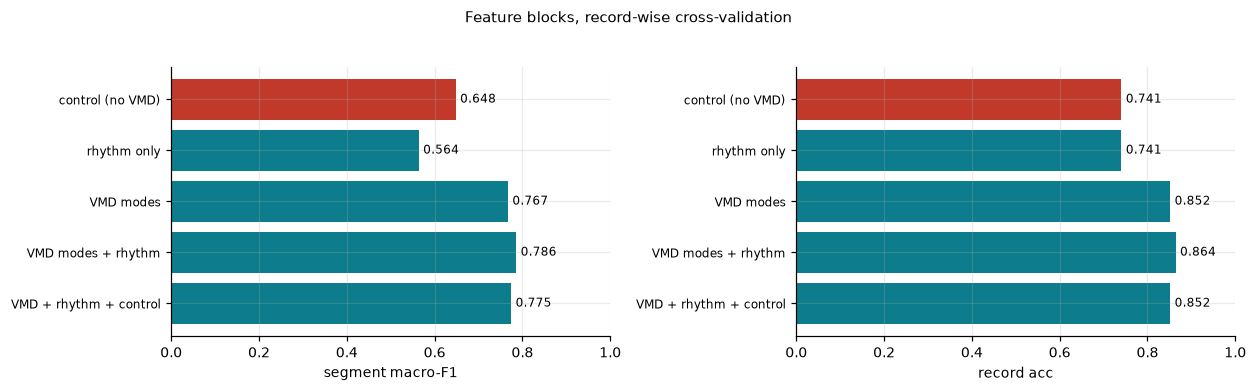

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
for ax, metric in zip(axes, ["segment macro-F1", "record acc"]):
    s = set_df[metric].dropna()
    cols = ["#c0392b" if "control" == i[:7] else "#0d7c8c" for i in s.index]
    ax.barh(range(len(s)), s.values[::-1], color=cols[::-1])
    ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index[::-1], fontsize=8)
    ax.set_xlabel(metric); ax.set_xlim(0, 1)
    for i, v in enumerate(s.values[::-1]):
        ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)
fig.suptitle("Feature blocks, record-wise cross-validation", y=1.03, fontsize=10)
fig.tight_layout(); plt.show()

## 3.3 Model comparison

The feature set matters more than the estimator, but it is worth confirming that rather
than assuming it.

In [34]:
X_best, best_names = fb["VMD modes + rhythm"]
model_rows = []
for name, m in E.default_models(cfg).items():
    s = E.evaluate(m, X_best, fb.y, fb.groups, cfg)
    model_rows.append({"model": name, **s})
    print(f"{name:24s} F1 {s['segment macro-F1']:.4f}  record {s['record acc']:.4f}")
model_df = pd.DataFrame(model_rows).set_index("model")

RandomForest             F1 0.7861  record 0.8642
ExtraTrees               F1 0.7795  record 0.8333
HistGradientBoosting     F1 0.7941  record 0.8457
LogReg (scaled)          F1 0.7921  record 0.8889


In [35]:
best_model_name = model_df["segment macro-F1"].idxmax()
best_model = E.default_models(cfg)[best_model_name]
scores, pred = E.evaluate(best_model, X_best, fb.y, fb.groups, cfg, return_pred=True)
print(E.report(fb.y, pred, fb.groups, title=f"{best_model_name} on VMD modes + rhythm"))

=== HistGradientBoosting on VMD modes + rhythm ===
segment level:
              precision    recall  f1-score   support

         ARR      0.843     0.889     0.865       960
         CHF      0.791     0.680     0.731       300
         NSR      0.797     0.775     0.786       360

    accuracy                          0.825      1620
   macro avg      0.810     0.781     0.794      1620
weighted avg      0.823     0.825     0.823      1620

record level (majority vote):
              precision    recall  f1-score   support

         ARR      0.846     0.917     0.880        96
         CHF      0.846     0.733     0.786        30
         NSR      0.844     0.750     0.794        36

    accuracy                          0.846       162
   macro avg      0.845     0.800     0.820       162
weighted avg      0.846     0.846     0.843       162

record confusion matrix (rows=true, order ARR,CHF,NSR):
[[88  3  5]
 [ 8 22  0]
 [ 8  1 27]]


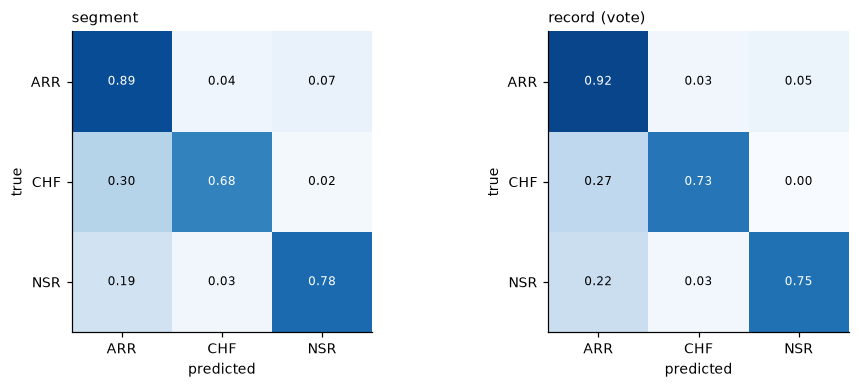

In [36]:
from sklearn.metrics import confusion_matrix
ry, rp = E.record_vote(pred, fb.groups, fb.y)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, (t, p, ttl) in zip(axes, [(fb.y, pred, "segment"), (ry, rp, "record (vote)")]):
    cm = confusion_matrix(t, p, labels=CLASS_ORDER, normalize="true")
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(3)); ax.set_xticklabels(CLASS_ORDER)
    ax.set_yticks(range(3)); ax.set_yticklabels(CLASS_ORDER)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.grid(False)
    ax.set_title(ttl, loc="left")
    for a in range(3):
        for b in range(3):
            ax.text(b, a, f"{cm[a,b]:.2f}", ha="center", va="center",
                    color="white" if cm[a, b] > 0.5 else "black", fontsize=8)
fig.tight_layout(); plt.show()

## 3.4 Mode ablation — is the high-frequency mode physiology or equipment?

The three classes come from three different source databases. If the model leans on
$u_K$, whose centre frequency sits above the physiological ECG band, the most likely
explanation is that it has learned to recognise the recording hardware.

Two measurements: how well each mode does *alone*, and how much is lost when each is
*removed*.

In [37]:
K = cfg.K
mode_of = np.array([int(n[1:n.index("_")]) if n.startswith("u") and n[1].isdigit() else 0
                    for n in best_names])
base = E.evaluate(E.rf(cfg), X_best, fb.y, fb.groups, cfg)["segment macro-F1"]

abl = []
for k in range(1, K + 1):
    alone = E.evaluate(E.rf(cfg), X_best[:, mode_of == k], fb.y, fb.groups, cfg)
    without = E.evaluate(E.rf(cfg), X_best[:, mode_of != k], fb.y, fb.groups, cfg)
    abl.append({"mode": f"u{k}", "alone": alone["segment macro-F1"],
                "loss when removed": base - without["segment macro-F1"]})
abl_df = pd.DataFrame(abl).set_index("mode")
print(f"full set: {base:.4f}\n")
print(abl_df.round(4).to_string())

full set: 0.7861

       alone  loss when removed
mode                           
u1    0.5783             0.0022
u2    0.5793             0.0018
u3    0.6634             0.0093
u4    0.6710             0.0011
u5    0.6671             0.0008
u6    0.6753             0.0074
u7    0.6401            -0.0005
u8    0.7430             0.0795


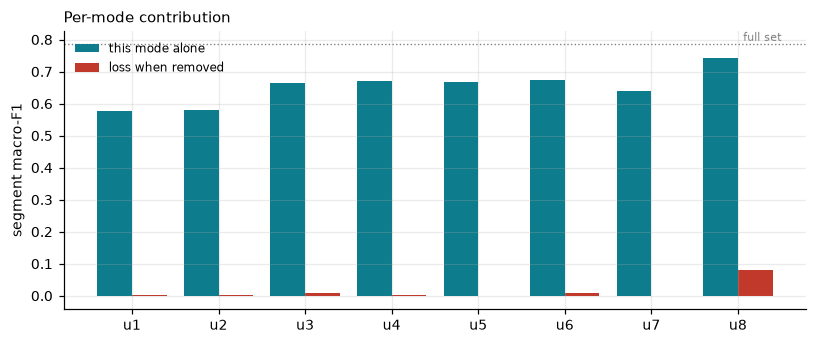

In [38]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
xp = np.arange(K)
ax.bar(xp - 0.2, abl_df["alone"], 0.4, label="this mode alone", color="#0d7c8c")
ax.bar(xp + 0.2, abl_df["loss when removed"], 0.4, label="loss when removed",
       color="#c0392b")
ax.axhline(base, ls=":", color="0.5", lw=0.9)
ax.text(K - 0.5, base + 0.01, "full set", fontsize=7, color="0.5", ha="right")
ax.set_xticks(xp); ax.set_xticklabels(abl_df.index)
ax.set_ylabel("segment macro-F1"); ax.legend(fontsize=8)
ax.set_title("Per-mode contribution", loc="left")
fig.tight_layout(); plt.show()

In [39]:
top_alone = abl_df["alone"].idxmax()
print(f"Strongest mode on its own: {top_alone} ({abl_df.loc[top_alone,'alone']:.4f})")
if top_alone in (f"u{K}", f"u{K-1}"):
    print("\nThis is the confound case. A high-frequency mode carrying most of the")
    print("signal is consistent with a device fingerprint, not with cardiac physiology.")
    print("The honest test is a held-out recording from a DIFFERENT database - which")
    print("this dataset cannot provide. Treat the headline number as an upper bound and")
    print(f"report the drop-u{K} score alongside it.")
    dropped = E.evaluate(E.rf(cfg), X_best[:, mode_of != K], fb.y, fb.groups, cfg)
    print(f"\nscore without u{K}: {dropped['segment macro-F1']:.4f} "
          f"(vs {base:.4f} with it)")

Strongest mode on its own: u8 (0.7430)

This is the confound case. A high-frequency mode carrying most of the
signal is consistent with a device fingerprint, not with cardiac physiology.
The honest test is a held-out recording from a DIFFERENT database - which
this dataset cannot provide. Treat the headline number as an upper bound and
report the drop-u8 score alongside it.

score without u8: 0.7066 (vs 0.7861 with it)


## 3.5 Reducing to a qubit-sized feature set

A variational quantum classifier encodes one feature per qubit under angle encoding.
236 features is not a circuit anyone is running soon; 8 to 16 is.

Naively taking the top 8 by ANOVA F fails here, because the 28 descriptors of a single
mode are heavily correlated — the top 8 would be eight views of the same thing.
**mRMR** (maximum relevance, minimum redundancy) greedily picks features that are
individually informative *and* mutually decorrelated.

Crucially, `MRMRSelector` is an sklearn transformer, so selection happens **inside each
training fold**. Ranking features on the whole dataset and then cross-validating would
leak the test labels into the feature choice.

In [40]:
from sklearn.pipeline import make_pipeline

sel_rows = []
for k in [4, 8, 12, 16, 24]:
    pipe = make_pipeline(E.MRMRSelector(k=k), E.rf(cfg))
    s = E.evaluate(pipe, X_best, fb.y, fb.groups, cfg)
    sel_rows.append({"n features": k, **s})
    print(f"k={k:3d}  F1 {s['segment macro-F1']:.4f}  record {s['record acc']:.4f}")
sel_df = pd.DataFrame(sel_rows).set_index("n features")
print(f"\nfull {X_best.shape[1]} features: F1 {base:.4f}")

k=  4  F1 0.6610  record 0.7531
k=  8  F1 0.7051  record 0.8210
k= 12  F1 0.7243  record 0.8148
k= 16  F1 0.7222  record 0.8025
k= 24  F1 0.7396  record 0.8210

full 236 features: F1 0.7861


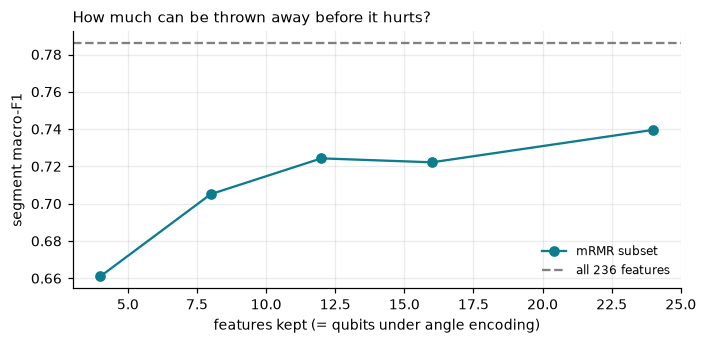

In [41]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(sel_df.index, sel_df["segment macro-F1"], "o-", color="#0d7c8c",
        label="mRMR subset")
ax.axhline(base, ls="--", color="0.5", label=f"all {X_best.shape[1]} features")
ax.set_xlabel("features kept (= qubits under angle encoding)")
ax.set_ylabel("segment macro-F1"); ax.legend(fontsize=8)
ax.set_title("How much can be thrown away before it hurts?", loc="left")
fig.tight_layout(); plt.show()

In [42]:
N_QUBITS = 12          # 12 > 8: k=12 scores 0.724 vs 0.705, and on a
                       # simulator the extra four qubits are free
sel = E.MRMRSelector(k=N_QUBITS).fit(X_best, fb.y)
chosen = list(np.array(best_names)[sel.idx_])
print(f"{N_QUBITS} features selected by mRMR (fitted on all data, for INSPECTION only):")
for i, n in enumerate(chosen, 1):
    print(f"  {i}. {n}")
print("\nNote how they spread across modes rather than clustering in one.")

12 features selected by mRMR (fitted on all data, for INSPECTION only):
  1. u5_tkeo
  2. u6_shannon
  3. u8_spec_entropy
  4. u5_spec_entropy
  5. u6_tkeo
  6. u4_spec_entropy
  7. u5_wave_len
  8. u8_spec_bandwidth
  9. u6_wave_len
  10. u6_spec_entropy
  11. u8_shannon
  12. recon_norm_ratio

Note how they spread across modes rather than clustering in one.


encoded: (1620, 12)  range [0.000, 3.142]  (target [0, pi])


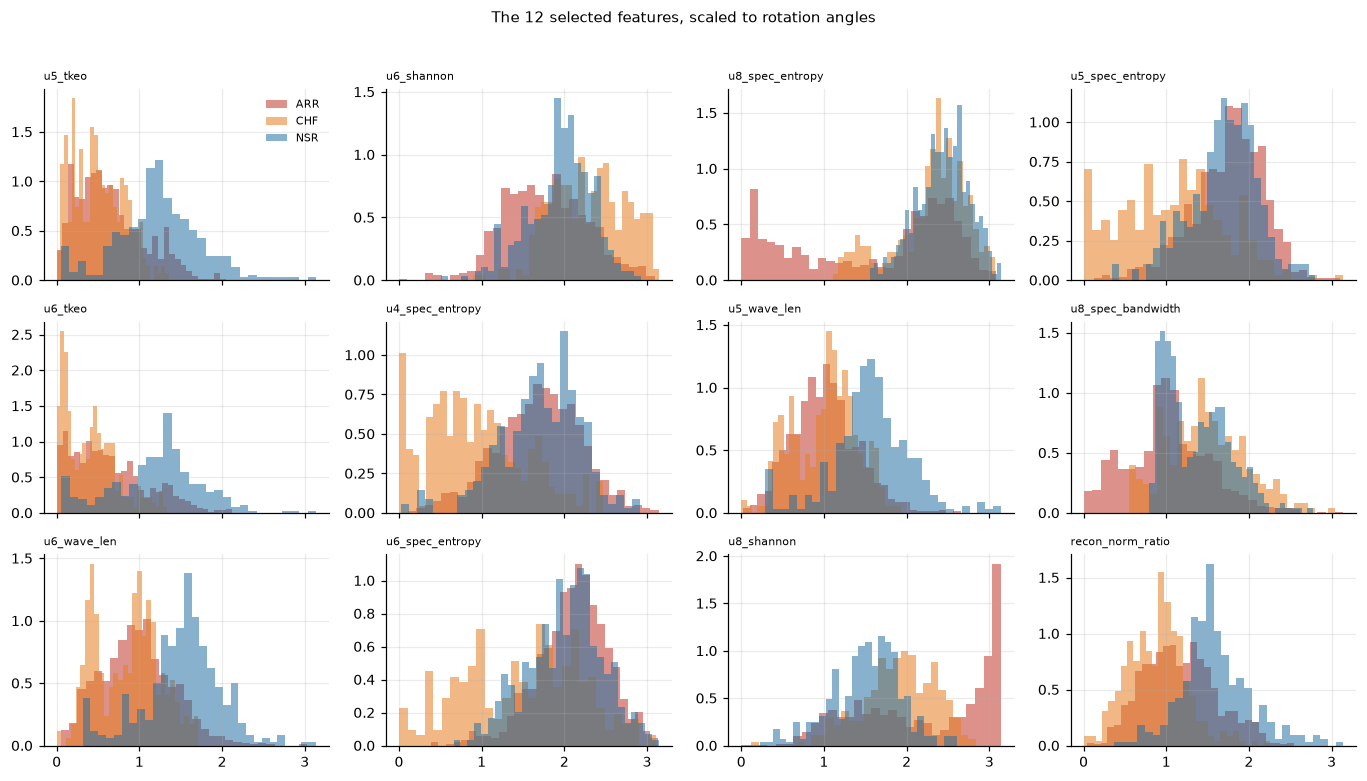

In [43]:
Xq, enc = E.quantum_ready(X_best, sel.idx_, mode="angle")
print(f"encoded: {Xq.shape}  range [{Xq.min():.3f}, {Xq.max():.3f}]  (target [0, pi])")

ncol = 4
nrow = int(np.ceil(N_QUBITS / ncol))          # grid follows N_QUBITS, never truncates
fig, axes = plt.subplots(nrow, ncol, figsize=(12.5, 2.3 * nrow), sharex=True,
                         squeeze=False)
for ax, j, n in zip(axes.ravel(), range(N_QUBITS), chosen):
    for cls in CLASS_ORDER:
        ax.hist(Xq[fb.y == cls, j], bins=30, alpha=0.55, density=True,
                color=CLASS_COLORS[cls], label=cls)
    ax.set_title(n, loc="left", fontsize=7)
for ax in axes.ravel()[N_QUBITS:]:
    ax.axis("off")                            # blank any unused panes
axes[0, 0].legend(fontsize=7)
fig.suptitle(f"The {N_QUBITS} selected features, scaled to rotation angles", y=1.02, fontsize=10)
fig.tight_layout(); plt.show()

## 3.6 Write the quantum handoff file

One `.npz` with everything a quantum model needs: the encoded features, the labels, the
**record ids** (so the quantum stage inherits the same honest splitting), the chosen
feature names, and the encoding parameters.

> **Read this before you trust the file.** Both the mRMR *selection* and the min/max
> *scaling* below are fitted on the whole dataset. That is a transductive leak — small,
> but real. It is done this way so the file is a fixed, inspectable artefact rather than
> something that changes per fold.
>
> The consequence: **a score computed by cross-validating on this file is optimistic.**
> The honest number is the `k=8` row of the mRMR table above, where selection happened
> inside each training fold. Two ways to stay honest downstream:
>
> * **preferred** — point the quantum stage at the *full* feature file and wrap its model
>   in `make_pipeline(MRMRSelector(k=8), quantum_model)`, exactly as done above; or
> * refit `quantum_ready` on the training fold only, using the returned `lo`/`hi` to
>   transform the test fold.
>
> `full_feature_file` is stored in the npz so the first option is always available.

In [44]:
os.makedirs("features", exist_ok=True)
qpath = f"features/quantum_{cfg.signature()}_q{N_QUBITS}.npz"
np.savez_compressed(
    qpath,
    X=Xq.astype(np.float32),          # angle-encoded, scaled on ALL data (see caveat above)
    X_raw=X_best[:, sel.idx_].astype(np.float32),   # same features, unscaled
    y=fb.y,
    groups=fb.groups,                 # record id - split on this, always
    feature_names=np.array(chosen, dtype=object),
    encoding=np.array(enc["mode"]),
    enc_lo=enc["lo"], enc_hi=enc["hi"],
    n_qubits=N_QUBITS,
    classical_baseline_f1=base,                     # all 236 features, honest CV
    classical_baseline_f1_k=sel_df.loc[N_QUBITS, "segment macro-F1"],  # in-fold mRMR at k=N_QUBITS
    full_feature_file=np.array(FEATURE_FILE),       # for in-fold selection downstream
)
print(f"wrote {qpath}  ({os.path.getsize(qpath)/1e3:.0f} kB)")
print()
print(f"numbers the quantum model has to beat:")
print(f"  {base:.4f}  macro-F1, all {X_best.shape[1]} features, record-wise CV")
print(f"  {sel_df.loc[N_QUBITS,'segment macro-F1']:.4f}  macro-F1, mRMR-{N_QUBITS} selected IN-FOLD  <- the fair one")

wrote features/quantum_fixed_K8_a2000_L500_it500_eeb2053b_q12.npz  (143 kB)

numbers the quantum model has to beat:
  0.7861  macro-F1, all 236 features, record-wise CV
  0.7243  macro-F1, mRMR-12 selected IN-FOLD  <- the fair one


---

## What comes next: the quantum model

This notebook ends with `features/quantum_*.npz` — the interface. Everything above it
is settled classical signal processing; everything below it is the quantum stage, and
nothing in the quantum stage should need to reach back into VMD.

The contract:

| array | shape | meaning |
|---|---|---|
| `X` | (n, q) | features scaled to [0, pi], ready for angle encoding |
| `X_raw` | (n, q) | the same features unscaled, if you prefer your own encoding |
| `y` | (n,) | ARR / CHF / NSR |
| `groups` | (n,) | **record id — split on this, always** |
| `classical_baseline_f1` | scalar | the number the quantum model has to beat |

Three things to hold onto when the quantum stage is built:

1. **The baseline is the point.** A hybrid quantum classifier that scores below the
   random forest above has demonstrated nothing. Record the comparison every time.
2. **`groups` still applies.** Quantum or not, a random split on this data inflates the
   score by ~0.12 macro-F1.
3. **Reproduce the classical result first.** Before adding a variational circuit,
   confirm that a small classical MLP on these same 8 features lands near
   `sel_df.loc[8]` above. If it does not, the problem is in the encoding, not the
   quantum layer — and that is much easier to diagnose now than later.